In [59]:
import pyspark
from pyspark import SparkContext
from pyspark.sql import SparkSession, SQLContext, DataFrameReader
from pyspark.sql.types import StringType, IntegerType, ArrayType, MapType
from pyspark.sql import functions as F
from pyspark.sql.functions import udf, col, max, desc
import matplotlib.pyplot as plt
import os

save_directory = '/home/ubuntu/celebrity_mentions/reddit_full/'

In [ ]:
from pyspark.sql import SparkSession
from operator import add

spark_session = SparkSession.builder\
        .master("spark://192.168.2.39:7077") \
        .appName("RedditDataProcessing_test")\
        .config("spark.dynamicAllocation.enabled", True)\
        .config("spark.dynamicAllocation.shuffleTracking.enabled",True)\
        .config("spark.shuffle.service.enabled", False)\
        .config("spark.dynamicAllocation.executorIdleTimeout","30s")\
        .config("spark.executor.cores", 2)\
        .config("spark.driver.port",9999)\
        .config("spark.blockManager.port",10005)\
        .config("spark.sql.shuffle.partitions", 200)\
        .getOrCreate()

# RDD API
spark_context = spark_session.sparkContext
spark_context.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/18 15:54:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [68]:
import pandas as pd
import numpy as np

reddit_data = spark_session.read.json("hdfs://192.168.2.156:9000/data/reddit/corpus-webis-tldr-17.json")
celebrity_data = spark_session.read.option("header", "true").csv("hdfs://192.168.2.156:9000/output/group31/Formatted_Celebrities.csv")
reddit_data.show(5)
celebrity_data.show(5)


null_counts = reddit_data.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in reddit_data.columns])
null_counts.show()

+----------------+--------------------+--------------------+-----------+-------+--------------------+-----------+------------+--------------------+-----------+--------+
|          author|                body|             content|content_len|     id|      normalizedBody|  subreddit|subreddit_id|             summary|summary_len|   title|
+----------------+--------------------+--------------------+-----------+-------+--------------------+-----------+------------+--------------------+-----------+--------+
|raysofdarkmatter|I think it should...|I think it should...|        178|c69al3r|I think it should...|       math|    t5_2qh0n|Shifting seasonal...|          8|    NULL|
|         Stork13|Art is about the ...|Art is about the ...|        148|c6a9nxd|Art is about the ...|      funny|    t5_2qh33|Personal opinions...|          4|    NULL|
|   Cloud_dreamer|Ask me what I thi...|Ask me what I thi...|         76|c6acx4l|Ask me what I thi...|Borderlands|    t5_2r8cd|insults and slack...|        

[Stage 172:====================================================>(146 + 1) / 147]

+------+----+-------+-----------+---+--------------+---------+------------+-------+-----------+-------+
|author|body|content|content_len| id|normalizedBody|subreddit|subreddit_id|summary|summary_len|  title|
+------+----+-------+-----------+---+--------------+---------+------------+-------+-----------+-------+
|     0|   0|      0|          0|  0|             0|      136|         136|      0|          0|2085301|
+------+----+-------+-----------+---+--------------+---------+------------+-------+-----------+-------+



In [61]:
total_records = reddit_data.count()

print(f"Total number of records in reddit_data: {total_records}")

[Stage 151:====================================================>(146 + 1) / 147]

Total number of records in reddit_data: 3848330


In [69]:
celebrity_names = celebrity_data.select("name").rdd.flatMap(lambda x: x).collect()

# Function to get the list of celebrity names mentioned and their counts
def get_celebrity_names_and_counts(comment_text):
    mentioned_names = []
    counts = []
    for name in celebrity_names:
        count = comment_text.lower().count(name.lower())
        if count > 0:
            mentioned_names.append(name)
            counts.append(count)
    return (mentioned_names, counts)

# Define a UDF (User Defined Function) to apply the function on each comment
get_celebrity_names_and_counts_udf = udf(get_celebrity_names_and_counts, ArrayType(ArrayType(StringType())))

# Apply the UDF to the `content` column to create a new column with the mentioned celebrity names and their counts
reddit_data_with_celebrity_names = reddit_data.withColumn("celebrity_names_and_counts", get_celebrity_names_and_counts_udf(F.col("content")))

# Split the tuple into two separate columns: 'celebrity_names' and 'celebrity_counts'
reddit_data_with_celebrity_names = reddit_data_with_celebrity_names.withColumn("celebrity_names", F.col("celebrity_names_and_counts").getItem(0)) \
    .withColumn("celebrity_counts", F.col("celebrity_names_and_counts").getItem(1))

# Drop the combined column 'celebrity_names_and_counts' and show the result
reddit_data_with_celebrity_names = reddit_data_with_celebrity_names.drop("celebrity_names_and_counts")

reddit_data_with_celebrity_names.select("content", "celebrity_names", "celebrity_counts").show(5)

+--------------------+---------------+----------------+
|             content|celebrity_names|celebrity_counts|
+--------------------+---------------+----------------+
|I think it should...|             []|              []|
|Art is about the ...|             []|              []|
|Ask me what I thi...|             []|              []|
|In Mechwarrior On...|             []|              []|
|You are talking a...|             []|              []|
+--------------------+---------------+----------------+
only showing top 5 rows



In [71]:
# Filter comments mentioning at least one celebrity
comments_with_mentions = reddit_data_with_celebrity_names.filter(F.size(F.col("celebrity_counts")) > 0)
comments_with_mentions.select("content", "celebrity_names", "celebrity_counts").show(5)


[Stage 177:>                                                        (0 + 1) / 1]

+--------------------+--------------------+----------------+
|             content|     celebrity_names|celebrity_counts|
+--------------------+--------------------+----------------+
|This is back when...|          [skrillex]|             [2]|
|I'm warning for a...|[madonna, michael...|          [5, 2]|
|Guess I'll throw ...|               [nas]|             [2]|
|This reminds me o...|               [nas]|             [1]|
|this is going to ...|              [pink]|             [1]|
+--------------------+--------------------+----------------+
only showing top 5 rows



In [72]:
# Explode the 'celebrity_names' and 'celebrity_counts' arrays into individual rows
exploded_data = reddit_data_with_celebrity_names.select(
    F.explode(F.arrays_zip("celebrity_names", "celebrity_counts")).alias("celebrity_count")
)

# Extract the 'celebrity' and 'count' from the struct using getField
exploded_data = exploded_data.select(
    F.col("celebrity_count").getField("celebrity_names").alias("celebrity"),
    F.col("celebrity_count").getField("celebrity_counts").alias("count")
)

# Group by celebrity name and sum the counts
celebrity_mentions_summary = exploded_data.groupBy("celebrity").agg(
    F.sum("count").alias("total_mentions")
)

# Sort the result by total mentions in descending order
celebrity_mentions_summary = celebrity_mentions_summary.orderBy(F.desc("total_mentions"))

# Show the result
celebrity_mentions_summary.show(10)


[Stage 178:====================================================>(146 + 1) / 147]

+----------+--------------+
| celebrity|total_mentions|
+----------+--------------+
|       nas|       87128.0|
|      pink|       25522.0|
|     usher|        7402.0|
|     drake|        5557.0|
|  ron paul|        4503.0|
|   pitbull|        1897.0|
|      kaka|        1565.0|
|      bono|        1366.0|
|  skrillex|        1141.0|
|bill gates|        1101.0|
+----------+--------------+
only showing top 10 rows



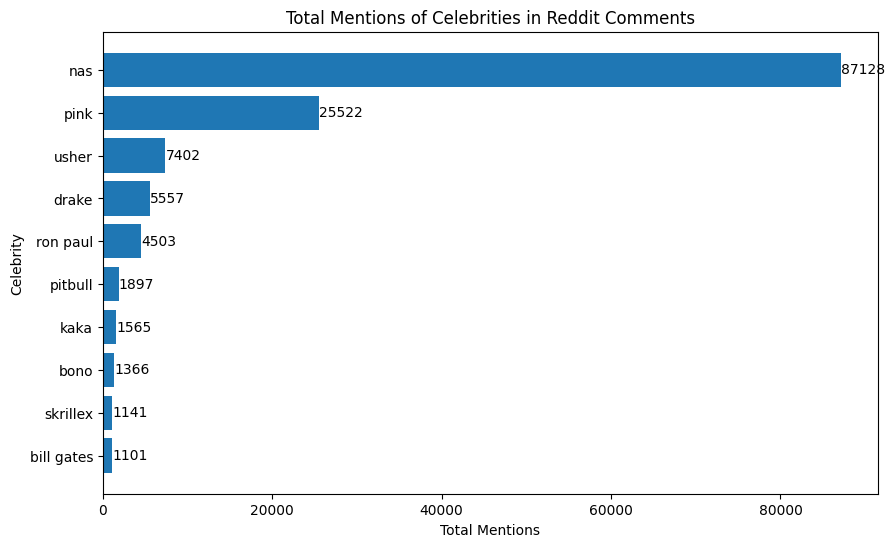

In [73]:
celebrity_mentions_pandas = celebrity_mentions_summary.toPandas()

top_10_celebs = celebrity_mentions_pandas.sort_values(by='total_mentions', ascending=False).head(10)

# Plotting the bar chart using matplotlib
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_celebs['celebrity'], top_10_celebs['total_mentions'])

# Adding labels and title
plt.xlabel('Total Mentions')
plt.ylabel('Celebrity')
plt.title('Total Mentions of Celebrities in Reddit Comments')

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, str(int(bar.get_width())), 
             va='center', ha='left', fontsize=10)

plt.savefig(os.path.join(save_directory, 'celebrity_mentions_plot_full.png'), bbox_inches='tight')
plt.show()


In [74]:
celebrity_mentions_pandas.to_csv(os.path.join(save_directory, 'celebrity_mentions_summary_full.csv'), index=False)
print("Files saved successfully!")


Files saved successfully!


In [75]:
spark_context.stop()